In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

### Practical Work 2

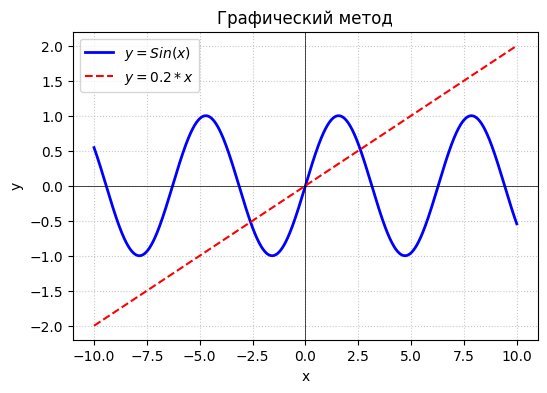

Корень уравнения: 2.596


In [46]:
def f(x):
    return np.sin(x) - 0.2 * x       #sin x - 0,2x = 0


def calculation(a, b, epsilon):
    # Условие для проверки условия теоремы Больцано-Коши
    if f(a) * f(b) > 0:
        print(f"На отрезке [{a};{b}] корней нет")
        return None
    iterations = 0
    result = 0
    while (b - a) / 2 > epsilon:
        iterations += 1
        result = (a + b) / 2
        # Выбираю половину отрезка, на которой функция меняет знак
        if f(a) * f(result) < 0:
            b = result
        else:
            a = result

    return result

def f1(x):
        return np.sin(x)


def f2(x):
        return 0.2 * x


# Выбираю диапазон x для визуализации
x = np.linspace(-10.0, 10, 1000)

# графики
plt.figure(figsize=(6, 4))
plt.plot(x, f1(x), label=r'$y = Sin(x)$', color='blue', linewidth=2)
plt.plot(x, f2(x), label=r'$y = 0.2 * x$', color='red', linestyle='--')

# Оформление и показ графика (Заголовок, оси координат, легенда и т. д.)
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.grid(True, linestyle=':', alpha=0.7)
plt.title('Графический метод')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

# Исходя из графического анализа, корень лежит в интервале [2; 3]
a, b = 2, 3
epsilon = 1e-3

result_root = calculation(a, b, epsilon)

if result_root is not None:
    print(f"Корень уравнения: {result_root:.3f}")

### Practical Work 3

In [ ]:
def calculation_method_iterations(x_0, epsilon):
    result = []
    x = x_0
    difference = 1
    iteration = 0
    
    while difference > epsilon:
        iteration += 1
        # формула для корня в интервале [2, 3]
        x_search = np.pi - np.asin(0.2 * x)
        difference = abs(x_search - x)
        
        # Сохраняю данные в список, чтобы потом создать таблицу
        result.append({
            "Итерация": iteration,
            "x_n": round(x, 3),
            "x_(n+1)": round(x_search, 3),
            "Разность": round(difference, 3)
        })
        
        x = x_search
        
    # Создаю таблицу
    df = pd.DataFrame(result)
    return df


result_df = calculation_method_iterations(x_0=2.6, epsilon=0.001)

print("Расчетная таблица метода итераций:")
print(result_df.to_string(index=False))     #to_string преобразует DataFrame в строку в формате удобном для консоли.

final_root = result_df["x_(n+1)"].iloc[-1]      # iloc - извлекает строку или столбец по их целочисленному индексу.
print(f"\nНайденный корень: {final_root:.3f}")


Расчетная таблица метода итераций:
 Итерация   x_n  x_(n+1)  Разность
        1 2.600    2.595     0.005
        2 2.595    2.596     0.001
        3 2.596    2.596     0.000

Найденный корень: 2.596


### Practical Work 4

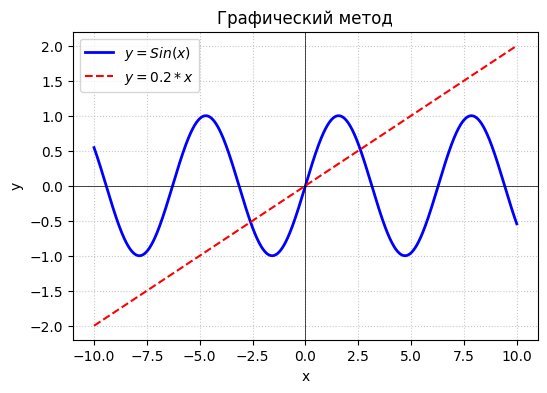

МЕТОД ХОРД:
  Итерация   x_n  f(x_n)  x_next  Разность
        1 2.000   0.509   2.526     0.526
        2 2.526   0.072   2.590     0.064
        3 2.590   0.006   2.595     0.005
        4 2.595   0.000   2.596     0.000

Найденный корень: 2.595

МЕТОД КАСАТЕЛЬНЫХ:
  Итерация   x_n  x_next  f(x_n)  f'(x_n)  Разность
        1 3.000  2.6144  -0.459   -1.190     0.386
        2 2.614  2.5958  -0.020   -1.064     0.019
        3 2.596  2.5957  -0.000   -1.055     0.000

Найденный корень: 2.596


In [45]:
def f(x): 
    return np.sin(x) - 0.2 * x


def df(x): 
    return np.cos(x) - 0.2


# Метод хорд с неподвижной точкой b
def chord_method(a, b, eps):
    data = []
    x_n = a

    while True:
        x_next = x_n - (f(x_n) * (b - x_n)) / (f(b) - f(x_n))
        difference = abs(x_next - x_n)
        
        data.append({
            "Итерация": len(data)+1,
            "x_n": round(x_n, 3), 
            "f(x_n)": round(f(x_n), 3),
            "x_next": round(x_next, 3),
            "Разность": round(difference, 3)})
        
        if difference < eps: 
            break
        x_n = x_next
    
    return pd.DataFrame(data)


# метод касательных
def newton_method(x_0, eps):
    result = []
    x_n = x_0

    while True:
        x_next = x_n - f(x_n) / df(x_n)
        difference = abs(x_next - x_n)

        result.append({
            "Итерация": len(result)+1,
            "x_n": round(x_n, 3), 
            "x_next": round(x_next, 4),
            "f(x_n)": round(f(x_n), 3),
            "f'(x_n)": round(df(x_n), 3),
            "Разность": round(difference, 3)})
        
        if difference < eps: 
            break
        x_n = x_next
    
    return pd.DataFrame(result)


def f1(x):
        return np.sin(x)


def f2(x):
        return 0.2 * x


# Выбираю диапазон x для визуализации
x = np.linspace(-10.0, 10, 1000)

# графики
plt.figure(figsize=(6, 4))
plt.plot(x, f1(x), label=r'$y = Sin(x)$', color='blue', linewidth=2)
plt.plot(x, f2(x), label=r'$y = 0.2 * x$', color='red', linestyle='--')

# Оформление и показ графика (Заголовок, оси координат, легенда)
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.grid(True, linestyle=':', alpha=0.7)
plt.title('Графический метод')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()


df_chord = chord_method(2.0, 3.0, 0.001)
df_newton = newton_method(3.0, 0.001)

print("МЕТОД ХОРД:\n", df_chord.to_string(index=False))
final_root = df_chord["x_n"].iloc[-1]      # iloc - извлекает строку или столбец по их целочисленному индексу.
print(f"\nНайденный корень: {final_root:.3f}")

print("\nМЕТОД КАСАТЕЛЬНЫХ:\n", df_newton.to_string(index=False))
final_root = df_newton["x_n"].iloc[-1]      # iloc - извлекает строку или столбец по их целочисленному индексу.
print(f"\nНайденный корень: {final_root:.3f}")


### Class

A:

In [8]:
class Parrot:
    def say(self):
        print("Привет, друзья!")

p = Parrot()
p.say()

Привет, друзья!


B:

In [10]:
class Parrot:
    def __init__(self, word):
        self.word = word
    def say(self):
        print(self.word)

p1 = Parrot("MyaW")
p2 = Parrot("Гав!")
p1.say()
p2.say()

MyaW
Гав!


C:

In [11]:
class Parrot:
    def __init__(self, word):
        self.word = word

    def newText(self, new_word):
        self.word = new_word

    def say(self):
        print(self.word)

p = Parrot("MyaW")
p.say()
p.newText("ГаВ!")
p.say()

MyaW
ГаВ!


D:

In [73]:
class Parrot:
    def __init__(self, word):
        self.word = word

    def newText(self, new_word):
        self.word = new_word

    def say(self, n=1):
        if n > 1:
            for _ in range(n):
                print(self.word, end=' ')
            print('\n')
        else:
            print(self.word)


p = Parrot("MyaW")
p.say()
p.newText("ГаВ!")
p.say(3)

MyaW
ГаВ! ГаВ! ГаВ! 



E:

In [67]:
from random import choice
class Parrot:
    def __init__(self, word):
        self.words = []
        self.words.append(word)

    def learn(self, new_word):
        self.words.append(new_word)
    
    def say(self, n=1):
        if n > 1:
            word = choice(self.words)
            for _ in range(n):
                print(word, end=' ')
            print('\n')
        else:
            print(choice(self.words))


p = Parrot("MyaW")
p.say()
p.learn("ГаВ!")
p.say(3)
p.say()

MyaW
MyaW MyaW MyaW 

ГаВ!


### Инкапсуляция

A:

In [ ]:
class LampRow:
    def __init__(self):
        self._state = "00000000"
        
    @property
    def state(self):
        return self._state

    @state.setter
    def state(self, new_state):
        if len(new_state) == 8:
            self._state = new_state
        else:
            self._state = "00000000"

    def show(self):
        display = ""
        for i in self._state:
            if i == '1':
                display += "*"
            else:
                display += "-"
                
        print(display)

lamps = LampRow()
lamps.show()
lamps.state = "10101010"
print(lamps.state)
lamps.show()


--------
10101010
*-*-*-*-


B:

In [80]:
class LampRow:
    def __init__(self, quanity):
        self.quanity = quanity
        self._state = "0" * self.quanity
        
    @property
    def state(self):
        return self._state

    @state.setter
    def state(self, new_state):
        if len(new_state) == self.quanity:
            self._state = new_state
        else:
            self._state = "0" * self.quanity

    def show(self):
        display = ""
        for i in self._state:
            if i == '1':
                display += "*"
            else:
                display += "-"
                
        print(display)

lamps = LampRow(6)
lamps.show()
lamps.state = "101010"
print(lamps.state)
lamps.show()
lamps.state = "10101010"
print(lamps.state)
lamps.show()


------
101010
*-*-*-
000000
------


C:

In [82]:
class LampRow:
    def __init__(self, quanity):
        self.quanity = quanity
        self._state = "0" * self.quanity
        
    @property
    def state(self):
        return self._state

    @state.setter
    def state(self, new_state):
        if len(new_state) == self.quanity:
            self._state = new_state
        else:
            self._state = "0" * self.quanity

    def show(self):
        display = ""
        for i in self._state:
            if i == '1':
                display += "*"
            elif i == '2':
                display += "o"
            else:
                display += "-"
                
        print(display)

lamps = LampRow(6)
lamps.show()
lamps.state = "102102"
print(lamps.state)
lamps.show()
lamps.state = "10201010"
print(lamps.state)
lamps.show()


------
102102
*-o*-o
000000
------


D:

In [ ]:
class LampRow:
    def __init__(self, quantity):
        self.quantity = quantity
        self._state_int = 0

    @property
    def state(self):
        return format(self._state_int, f'0{self.quantity}d')

    @state.setter
    def state(self, new_state):
        if len(new_state) == self.quantity:
            self._state_int = int(new_state)
        else:
            self._state_int = 0

    def show(self):
        current_state_str = self.state 
        display = ""
        for i in current_state_str:
            if i == '1':
                display += "*"
            elif i == '2':
                display += "o"
            else:
                display += "-"
                
        print(display)


lamps = LampRow(6)
lamps.show()
lamps.state = "102102"
print(lamps.state) 
lamps.show()       
lamps.state = "10201010" 
print(lamps.state) 
lamps.show()      


------
102102
*-o*-o
000000
------
